In [2]:
# ______STEP 1: Load the data_____
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
# Load directly from the web (no upload needed!)
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

In [4]:
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [5]:
print("_____________head of the dataset___________",df.head(5))



_____________head of the dataset___________    PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0   

In [18]:
print("_________Shape of the dataset________")
print(df.shape)

_________Shape of the dataset________
(891, 12)


In [7]:
print("______Information of the dataset_______", df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
______Information of the dataset_______ None


In [16]:
print("="*60)
print("       the statical summary of the dataset")
print("="*60)
print(df.describe())

       the statical summary of the dataset
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


# Checking whether the target column is balanced or not

In [22]:
print("======value count=======")
print(df["Survived"].value_counts())
print("/npersentage")
print(df["Survived"].value_counts(normalize=True)*100)
print("======================")

======value count=======
Survived
0    549
1    342
Name: count, dtype: int64
/npersentage
Survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


# visulize the target column by graph

# now we will cheak survival rate by class

In [42]:
print(df.groupby("Pclass")["Survived"].mean().apply(lambda x: f'{x*100:.1f}%'))
print("/npersentage")
print(df["Pclass"].value_counts().sort_index())

Pclass
1    63.0%
2    47.3%
3    24.2%
Name: Survived, dtype: object
/npersentage
Pclass
1    216
2    184
3    491
Name: count, dtype: int64


/tmp/ipykernel_19873/2974210372.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Pclass", y="Survived", data=df, palette=['#1D9E75','#EF9F27','#E24B4A'])


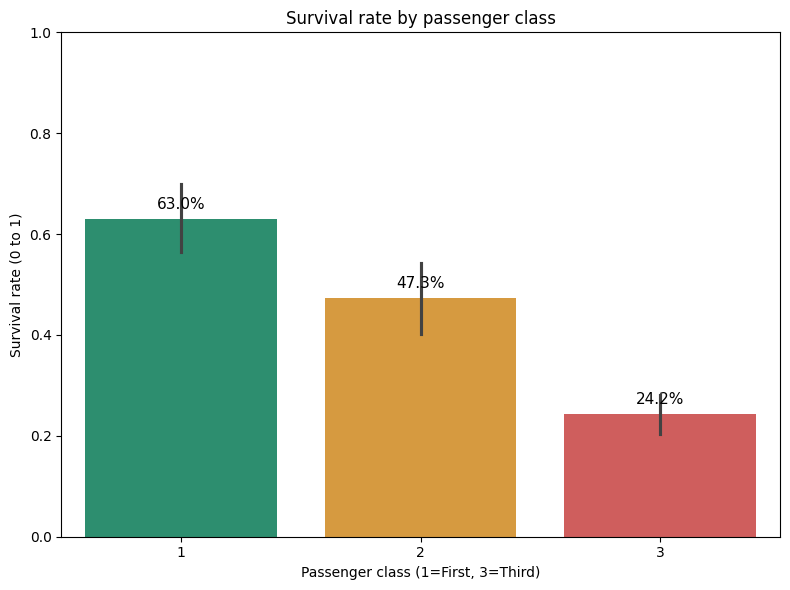

In [52]:
import seaborn as sns
plt.figure(figsize=(8,6))
sns.barplot(x="Pclass", y="Survived", data=df, palette=['#1D9E75','#EF9F27','#E24B4A'])
plt.title('Survival rate by passenger class')
plt.xlabel('Passenger class (1=First, 3=Third)')
plt.ylabel('Survival rate (0 to 1)')
plt.ylim(0, 1)
# Add % labels on top of each bar
for p in plt.gca().patches:
    plt.annotate(f'{p.get_height()*100:.1f}%',
                 (p.get_x() + p.get_width()/2, p.get_height() + 0.02),
                 ha='center', fontsize=11)

plt.tight_layout()
plt.show()

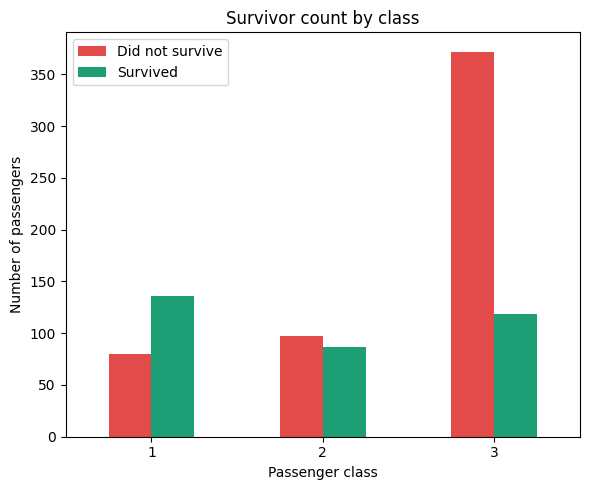

In [53]:
# WHY this chart: count shows how many people were actually in each group
# A 100% survival rate means nothing if only 2 people were in that group

survival_class = df.groupby(['Pclass', 'Survived']).size().unstack()

survival_class.plot(kind='bar',
                    color=['#E24B4A', '#1D9E75'],
                    edgecolor='none',
                    figsize=(6, 5))

plt.title('Survivor count by class')
plt.xlabel('Passenger class')
plt.ylabel('Number of passengers')
plt.legend(['Did not survive', 'Survived'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# **now survival rate of AGE**

In [59]:
print("="*40)
print("        Age column summary   ")
print("="*40)
print(df["Age"].describe())


        Age column summary   
count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64


In [61]:
print("="*40)
print("         missing values in Age   ")
print("="*40)
print(df["Age"].isnull().sum())
print(f"That is {df['Age'].isnull().mean()*100:.1f}% of all passengers")

         missing values in Age   
177
That is 19.9% of all passengers


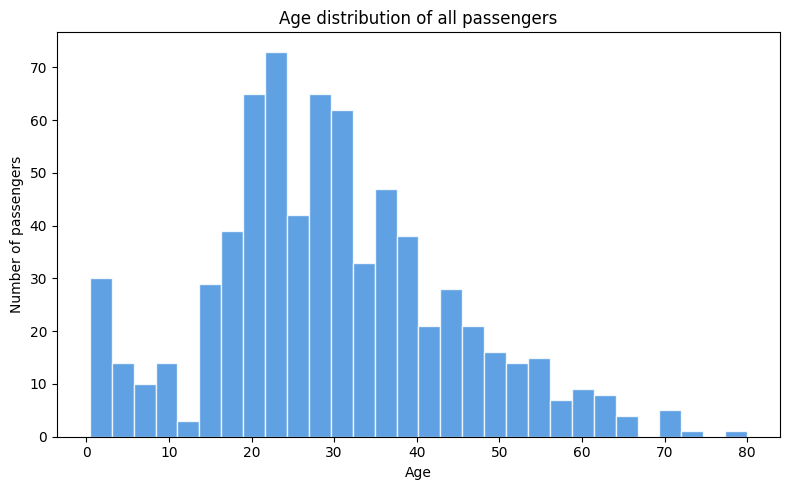

Average age: 29.7 years
Youngest: 0.42 years
Oldest:   80.0 years


In [63]:
# first understand the overall age spread of ALL passengers

plt.figure(figsize=(8, 5))
df['Age'].plot(kind='hist', bins=30,
               color='#378ADD', edgecolor='white', alpha=0.8)

plt.title('Age distribution of all passengers')
plt.xlabel('Age')
plt.ylabel('Number of passengers')
plt.tight_layout()
plt.show()

print(f"Average age: {df['Age'].mean():.1f} years")
print(f"Youngest: {df['Age'].min()} years")
print(f"Oldest:   {df['Age'].max()} years")

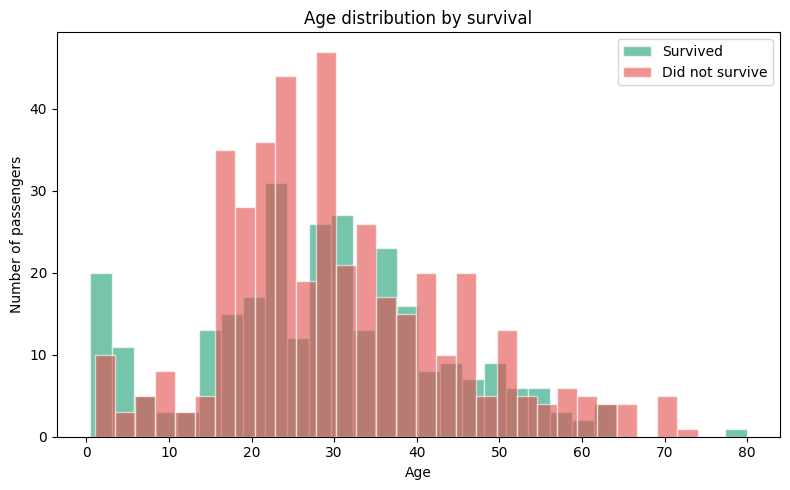

In [64]:
# which age groups survived  vs died more

plt.figure(figsize=(8, 5))

df[df['Survived'] == 1]['Age'].plot(
    kind='hist', bins=30, alpha=0.6,
    color='#1D9E75', label='Survived', edgecolor='white')

df[df['Survived'] == 0]['Age'].plot(
    kind='hist', bins=30, alpha=0.6,
    color='#E24B4A', label='Did not survive', edgecolor='white')

plt.title('Age distribution by survival')
plt.xlabel('Age')
plt.ylabel('Number of passengers')
plt.legend()
plt.tight_layout()
plt.show()

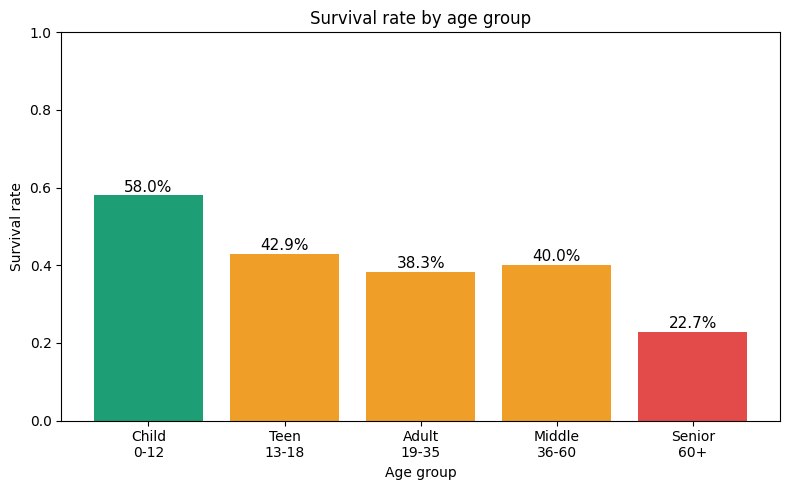

In [66]:
# Binning age into groups makes the pattern crystal clear.

df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[0, 12, 18, 35, 60, 100],
                         labels=['Child\n0-12', 'Teen\n13-18',
                                 'Adult\n19-35', 'Middle\n36-60',
                                 'Senior\n60+'])

plt.figure(figsize=(8, 5))
survival_by_age = df.groupby('AgeGroup', observed=False)['Survived'].mean()
colors = ['#1D9E75' if v > 0.45 else '#EF9F27' if v > 0.35 else '#E24B4A'
          for v in survival_by_age]

bars = plt.bar(survival_by_age.index,
               survival_by_age.values,
               color=colors, edgecolor='none')

# Add % labels
for bar, val in zip(bars, survival_by_age.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 0.01, f'{val*100:.1f}%',
             ha='center', fontsize=11)

plt.title('Survival rate by age group')
plt.xlabel('Age group')
plt.ylabel('Survival rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

# Drop the temp column after use
df.drop('AgeGroup', axis=1, inplace=True)

In [71]:
print("="*40)
print("    missing values in the dataset  ")
print("="*40)
for col in df.columns:
  missing_va=df[col].isnull().sum()
  persentage= df[col].isnull().mean()*100
  if missing_va > 0:
    print(f"{col:15} {missing_va:5} missing  ({persentage:.1f}%)")

    missing values in the dataset  
Age               177 missing  (19.9%)
Cabin             687 missing  (77.1%)
Embarked            2 missing  (0.2%)


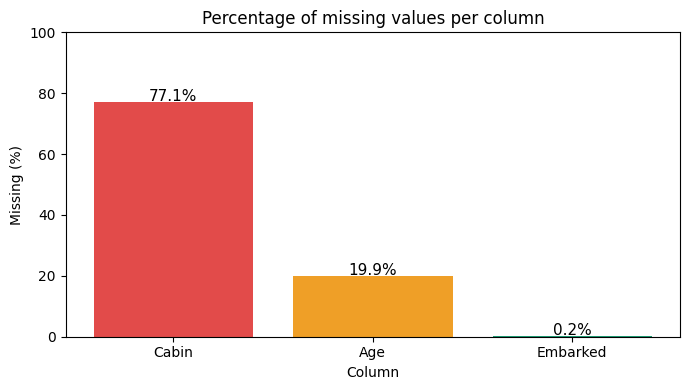

In [73]:
# how much data is missing per column

missing_va = df.isnull().sum()
missing_va= missing_va[missing_va > 0].sort_values(ascending=False)
percent = (missing_va / len(df) * 100)

plt.figure(figsize=(7, 4))
colors = ['#E24B4A' if p > 50 else '#EF9F27' if p > 10 else '#1D9E75'
          for p in percent]

bars = plt.bar(missing_va.index, percent.values,
               color=colors, edgecolor='none')

# Add % label on each bar
for bar, val in zip(bars, percent.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 0.5, f'{val:.1f}%',
             ha='center', fontsize=11)

plt.title('Percentage of missing values per column')
plt.xlabel('Column')
plt.ylabel('Missing (%)')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# **heatmap where missing**

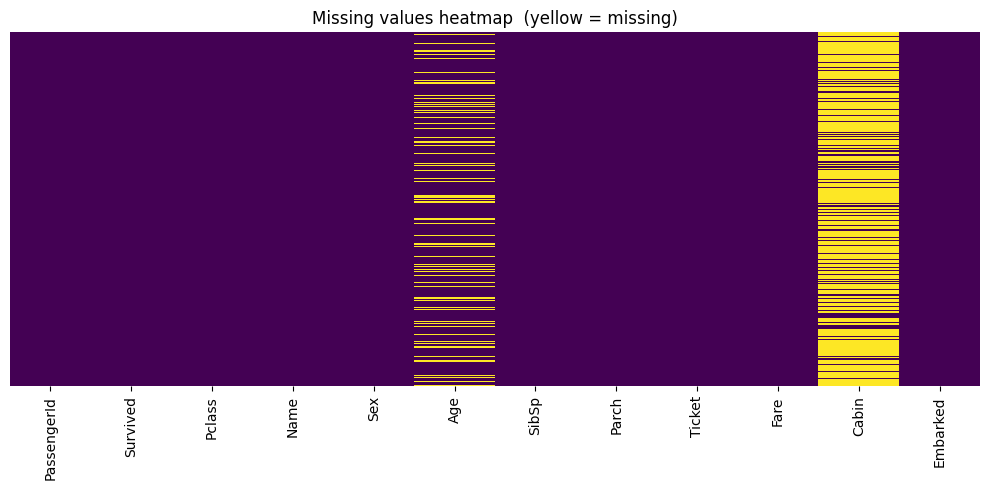

In [78]:
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(),
            cbar=False,
            cmap='viridis',
            yticklabels=False)

plt.title('Missing values heatmap  (yellow = missing)')
plt.tight_layout()
plt.show()

In [79]:
# Install missingno
!pip install missingno

import missingno as msno
import matplotlib.pyplot as plt

print("missingno ready!")

missingno ready!


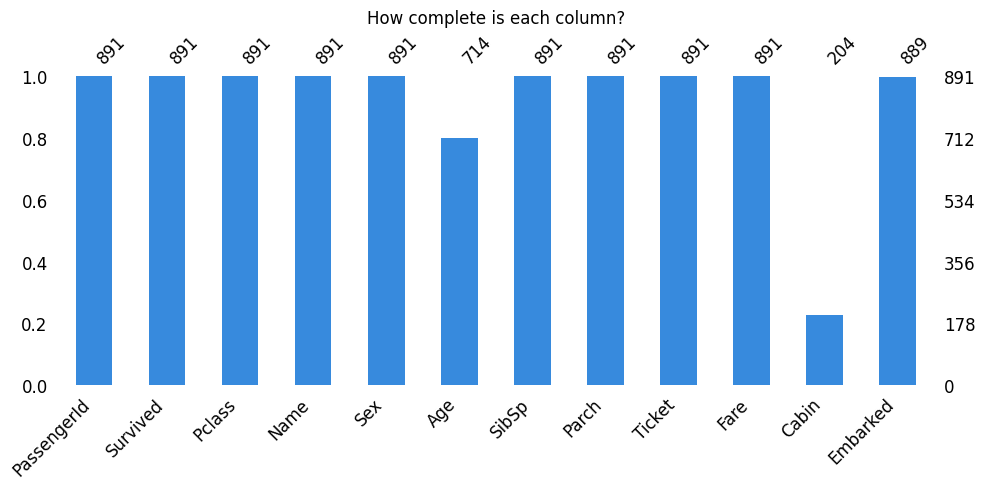

In [80]:

msno.bar(df, color='#378ADD', figsize=(10, 5), fontsize=12)
plt.title('How complete is each column?')
plt.tight_layout()
plt.show()

/tmp/ipykernel_19873/323130591.py:3: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


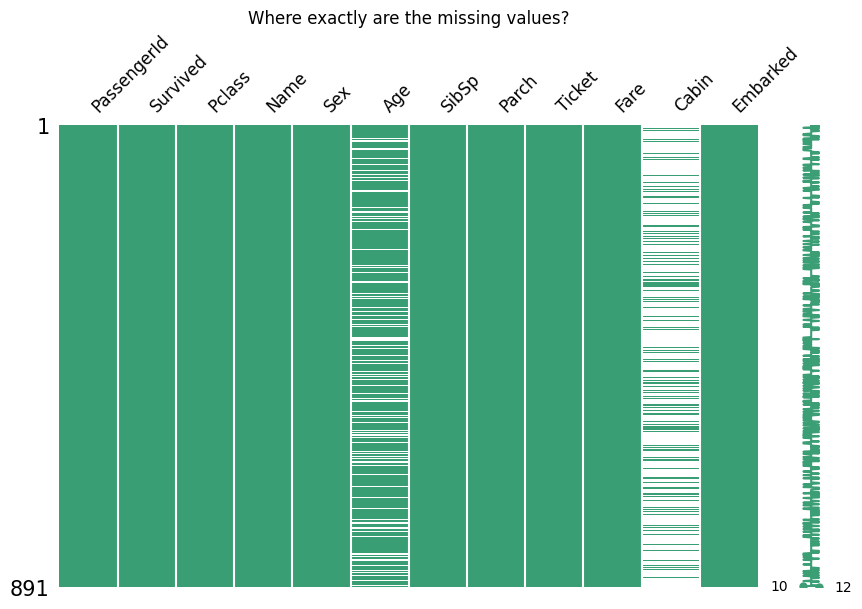

In [81]:

msno.matrix(df, color=(0.23, 0.62, 0.46), figsize=(10, 6), fontsize=12)
plt.title('Where exactly are the missing values?')
plt.tight_layout()
plt.show()

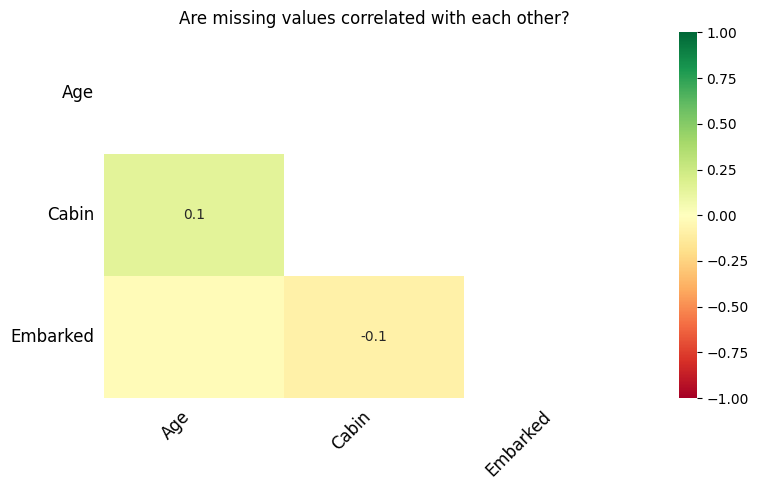

In [82]:
msno.heatmap(df, figsize=(8, 5), fontsize=12,
             cmap='RdYlGn')
plt.title('Are missing values correlated with each other?')
plt.tight_layout()
plt.show()

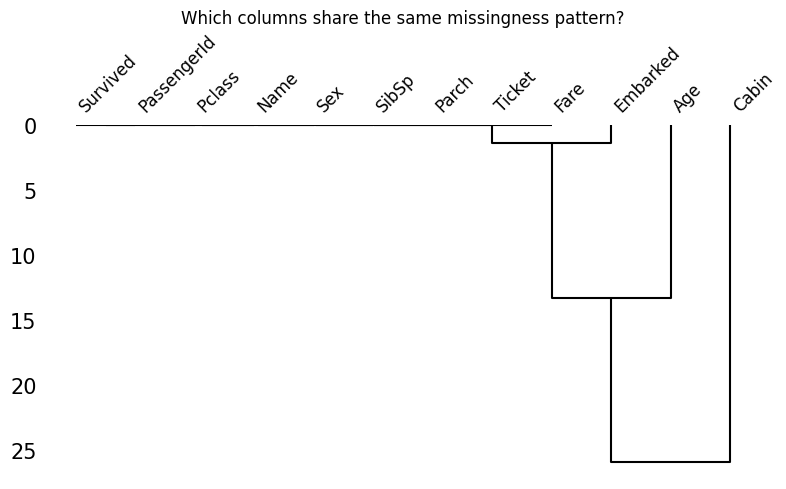

In [83]:

msno.dendrogram(df, figsize=(8, 5), fontsize=12)
plt.title('Which columns share the same missingness pattern?')
plt.tight_layout()
plt.show()

# **clean the data**

In [84]:
# save the copy of the orginal data
df_original = df.copy()

print(f"Shape: {df.shape}")
print(f"Missing values:\n{df.isnull().sum()[df.isnull().sum() > 0]}")

Shape: (891, 12)
Missing values:
Age         177
Cabin       687
Embarked      2
dtype: int64


In [93]:
df = df_original.copy()
cols_to_drop=["PassengerId", "Name", "Cabin", "Ticket"]
df=df.drop(columns=cols_to_drop)
print("After droping ")
print(df.columns.tolist())
print("shape of the dataset")
print(df.shape)

After droping 
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
shape of the dataset
(891, 8)


In [94]:
print(df.groupby('Pclass')['Age'].median())

# Fill missing Age with median of their own Pclass group
df['Age'] = df.groupby('Pclass')['Age'].transform(
    lambda x: x.fillna(x.median())
)

print(f"\nMissing Age values after filling: {df['Age'].isnull().sum()}")

Pclass
1    37.0
2    29.0
3    24.0
Name: Age, dtype: float64

Missing Age values after filling: 0


In [95]:

most_common_port = df['Embarked'].mode()[0]
print(f"Most common port: {most_common_port}")

df['Embarked'] = df['Embarked'].fillna(most_common_port)

print(f"Missing Embarked after filling: {df['Embarked'].isnull().sum()}")

Most common port: S
Missing Embarked after filling: 0


In [96]:
# encoding male= o and female= 1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print("Sex column after encoding:")
print(df['Sex'].value_counts())
print("\nSample:")
print(df[['Sex']].head())

Sex column after encoding:
Sex
0    577
1    314
Name: count, dtype: int64

Sample:
   Sex
0    0
1    1
2    1
3    1
4    0


In [97]:
# hot encoding
df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

print("Columns after encoding Embarked:")
print(df.columns.tolist())
print(f"\nShape now: {df.shape}")

Columns after encoding Embarked:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']

Shape now: (891, 9)


# **confirm everything is clean before moving to the model**

In [98]:
print("="*45)
print("FINAL CLEANED DATASET")
print("="*45)
print(f"Shape: {df.shape}")
print(f"\nMissing values: {df.isnull().sum().sum()} total")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()

FINAL CLEANED DATASET
Shape: (891, 9)

Missing values: 0 total

Data types:
Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_Q       bool
Embarked_S       bool
dtype: object

First 5 rows:


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked_Q,Embarked_S
0,0,3,0,22.0,1,0,7.2500,False,True
1,1,1,1,38.0,1,0,71.2833,False,False
2,1,3,1,26.0,0,0,7.9250,False,True
3,1,1,1,35.0,1,0,53.1000,False,True
4,0,3,0,35.0,0,0,8.0500,False,True


In [99]:
# Some ML models handle bool fine but int is safer and more universal

df['Embarked_Q'] = df['Embarked_Q'].astype(int)
df['Embarked_S'] = df['Embarked_S'].astype(int)

print("Fixed! Data types now:")
print(df.dtypes)

Fixed! Data types now:
Survived        int64
Pclass          int64
Sex             int64
Age           float64
SibSp           int64
Parch           int64
Fare          float64
Embarked_Q      int64
Embarked_S      int64
dtype: object


In [100]:

X = df.drop('Survived', axis=1)  # everything except target
y = df['Survived']                # only the target

print("Features (X) shape:", X.shape)
print("Target (y) shape  :", y.shape)
print("\nFeature columns:")
print(X.columns.tolist())

Features (X) shape: (891, 8)
Target (y) shape  : (891,)

Feature columns:
['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked_Q', 'Embarked_S']


In [101]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set   : {X_train.shape[0]} passengers (80%)")
print(f"Test set       : {X_test.shape[0]} passengers (20%)")
print(f"\nSurvival rate in train: {y_train.mean()*100:.1f}%")
print(f"Survival rate in test : {y_test.mean()*100:.1f}%")

Training set   : 712 passengers (80%)
Test set       : 179 passengers (20%)

Survival rate in train: 37.6%
Survival rate in test : 41.3%


In [102]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")
print(f"Number of trees: {model.n_estimators}")
print(f"Features used  : {model.n_features_in_}")

Model trained successfully!
Number of trees: 100
Features used  : 8


In [103]:


y_pred = model.predict(X_test)

print("Predictions made on test set!")
print(f"\nFirst 10 actual values    : {list(y_test[:10])}")
print(f"First 10 predicted values : {list(y_pred[:10])}")

Predictions made on test set!

First 10 actual values    : [1, 0, 0, 1, 1, 1, 1, 0, 1, 1]
First 10 predicted values : [np.int64(0), np.int64(0), np.int64(0), np.int64(1), np.int64(0), np.int64(1), np.int64(1), np.int64(0), np.int64(1), np.int64(1)]


In [104]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy*100:.2f}%")
print("\nFull classification report:")
print(classification_report(y_test, y_pred,
      target_names=['Did not survive', 'Survived']))

Accuracy: 83.24%

Full classification report:
                 precision    recall  f1-score   support

Did not survive       0.85      0.87      0.86       105
       Survived       0.81      0.78      0.79        74

       accuracy                           0.83       179
      macro avg       0.83      0.83      0.83       179
   weighted avg       0.83      0.83      0.83       179



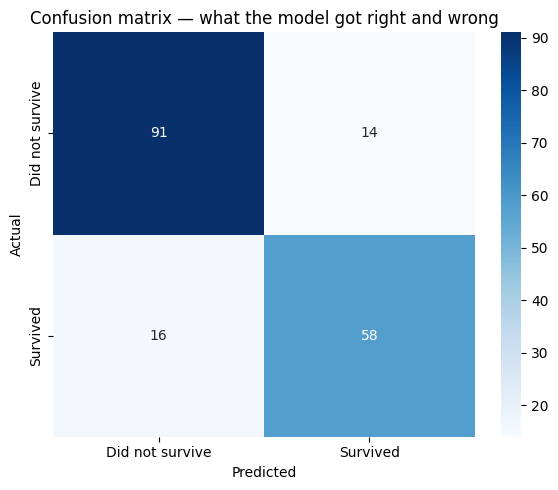


True Negative  (predicted death,  actually died)     : 91
False Positive (predicted survival, actually died)   : 14
False Negative (predicted death,  actually survived) : 16
True Positive  (predicted survival, actually survived): 58


In [105]:
import seaborn as sns
import matplotlib.pyplot as plt



cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did not survive', 'Survived'],
            yticklabels=['Did not survive', 'Survived'])
plt.title('Confusion matrix — what the model got right and wrong')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Plain English breakdown
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negative  (predicted death,  actually died)     : {tn}")
print(f"False Positive (predicted survival, actually died)   : {fp}")
print(f"False Negative (predicted death,  actually survived) : {fn}")
print(f"True Positive  (predicted survival, actually survived): {tp}")

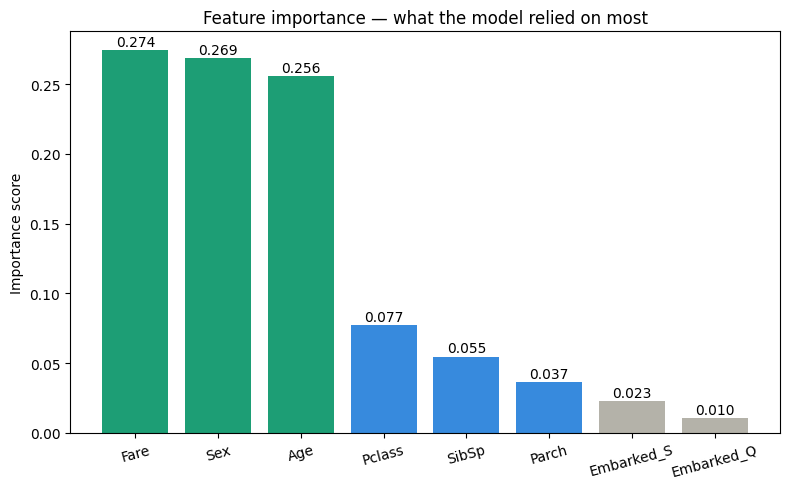


Feature importance ranked:
  Fare            0.2742
  Sex             0.2688
  Age             0.2557
  Pclass          0.0772
  SibSp           0.0547
  Parch           0.0365
  Embarked_S      0.0225
  Embarked_Q      0.0103


In [106]:


import pandas as pd

importance = pd.Series(model.feature_importances_,
                       index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
colors = ['#1D9E75' if i < 3 else '#378ADD' if i < 6 else '#B4B2A9'
          for i in range(len(importance))]

bars = plt.bar(importance.index, importance.values,
               color=colors, edgecolor='none')

for bar, val in zip(bars, importance.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + 0.003, f'{val:.3f}',
             ha='center', fontsize=10)

plt.title('Feature importance — what the model relied on most')
plt.ylabel('Importance score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print("\nFeature importance ranked:")
for feat, score in importance.items():
    print(f"  {feat:15} {score:.4f}")